In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
DATA_PATH = Path("../data/raw/creditcard.csv")

df = pd.read_csv(DATA_PATH)
df = df.sort_values("Time").reset_index(drop=True)

train_end = int(len(df) * 0.60)
validation_end = int(len(df) * 0.80)

train_df = df.iloc[:train_end].copy()
validation_df = df.iloc[train_end:validation_end].copy()
test_df = df.iloc[validation_end:].copy()

FEATURES = [column for column in df.columns if column != "Class"]

X_train = train_df[FEATURES]
y_train = train_df["Class"]

X_validation = validation_df[FEATURES]
y_validation = validation_df["Class"]

X_test = test_df[FEATURES]
y_test = test_df["Class"]

print(f"Validation transactions: {len(validation_df):,}")
print(f"Validation fraud cases: {y_validation.sum():,}")

Validation transactions: 56,961
Validation fraud cases: 57


In [6]:
scale_features = ["Time", "Amount"]
pca_features = [f"V{i}" for i in range(1, 29)]

preprocessor = ColumnTransformer(
    transformers=[
        ("scaled", RobustScaler(), scale_features),
        ("pca", "passthrough", pca_features),
    ]
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

logistic_model.fit(X_train, y_train)

validation_scores = logistic_model.predict_proba(
    X_validation
)[:, 1]

print(
    "Validation average precision:",
    round(
        average_precision_score(
            y_validation,
            validation_scores,
        ),
        4,
    ),
)

Validation average precision: 0.7727


In [7]:
REVIEW_CAPACITY = 100

ranked_indices = np.argsort(validation_scores)[::-1]
review_indices = ranked_indices[:REVIEW_CAPACITY]

capacity_predictions = np.zeros(
    len(y_validation),
    dtype=int,
)
capacity_predictions[review_indices] = 1

capacity_threshold = validation_scores[review_indices[-1]]

print(f"Review capacity: {REVIEW_CAPACITY}")
print(f"Score threshold: {capacity_threshold:.6f}")
print(f"Transactions flagged: {capacity_predictions.sum()}")

Review capacity: 100
Score threshold: 0.986487
Transactions flagged: 100


In [8]:
tn, fp, fn, tp = confusion_matrix(
    y_validation,
    capacity_predictions,
).ravel()

precision = precision_score(
    y_validation,
    capacity_predictions,
)

recall = recall_score(
    y_validation,
    capacity_predictions,
)

print(f"True positives:  {tp}")
print(f"False positives: {fp}")
print(f"False negatives: {fn}")
print(f"True negatives:  {tn}")
print()
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")

True positives:  45
False positives: 55
False negatives: 12
True negatives:  56849

Precision: 45.00%
Recall:    78.95%


In [9]:
def evaluate_capacity(y_true, scores, capacity):
    y_array = np.asarray(y_true)
    ranked = np.argsort(scores)[::-1]
    selected = ranked[:capacity]

    predictions = np.zeros(len(y_array), dtype=int)
    predictions[selected] = 1

    tn, fp, fn, tp = confusion_matrix(
        y_array,
        predictions,
    ).ravel()

    return {
        "review_capacity": capacity,
        "score_threshold": scores[selected[-1]],
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "precision": tp / (tp + fp),
        "recall": tp / (tp + fn),
        "alerts_per_1000": capacity / len(y_array) * 1000,
    }

In [10]:
capacity_results = pd.DataFrame(
    [
        evaluate_capacity(
            y_validation,
            validation_scores,
            capacity,
        )
        for capacity in [25, 50, 100, 250, 500, 1000]
    ]
)

capacity_results

,review_capacity,score_threshold,true_positives,false_positives,false_negatives,precision,recall,alerts_per_1000
0,25,1.000000,25,0,32,1.000,0.438596,0.438897
1,50,0.999968,41,9,16,0.820,0.719298,0.877794
2,100,0.986487,45,55,12,0.450,0.789474,1.755587
3,250,0.921972,46,204,11,0.184,0.807018,4.388968
4,500,0.817668,49,451,8,0.098,0.859649,8.777936
5,1000,0.669939,49,951,8,0.049,0.859649,17.555872


In [11]:
capacity_display = capacity_results.copy()

capacity_display["precision"] = (
    capacity_display["precision"].map("{:.2%}".format)
)

capacity_display["recall"] = (
    capacity_display["recall"].map("{:.2%}".format)
)

capacity_display["score_threshold"] = (
    capacity_display["score_threshold"].map("{:.6f}".format)
)

capacity_display

,review_capacity,score_threshold,true_positives,false_positives,false_negatives,precision,recall,alerts_per_1000
0,25,1.000000,25,0,32,100.00%,43.86%,0.438897
1,50,0.999968,41,9,16,82.00%,71.93%,0.877794
2,100,0.986487,45,55,12,45.00%,78.95%,1.755587
3,250,0.921972,46,204,11,18.40%,80.70%,4.388968
4,500,0.817668,49,451,8,9.80%,85.96%,8.777936
5,1000,0.669939,49,951,8,4.90%,85.96%,17.555872


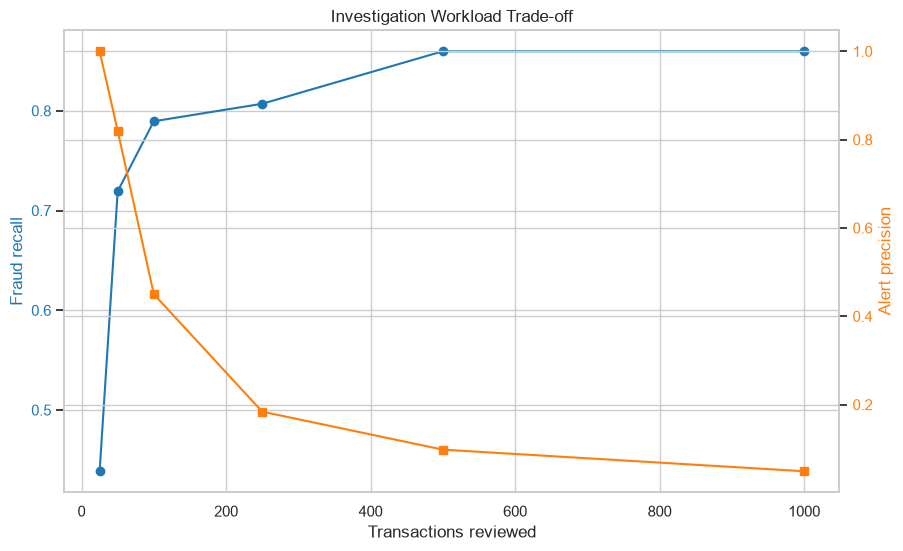

In [12]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(
    capacity_results["review_capacity"],
    capacity_results["recall"],
    marker="o",
    color="tab:blue",
    label="Recall",
)

ax1.set_xlabel("Transactions reviewed")
ax1.set_ylabel("Fraud recall", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()

ax2.plot(
    capacity_results["review_capacity"],
    capacity_results["precision"],
    marker="s",
    color="tab:orange",
    label="Precision",
)

ax2.set_ylabel("Alert precision", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("Investigation Workload Trade-off")
plt.show()

In [13]:
validation_analysis = validation_df.copy()

validation_analysis["risk_score"] = validation_scores
validation_analysis["flagged_for_review"] = capacity_predictions

validation_analysis["outcome"] = np.select(
    [
        (validation_analysis["Class"] == 1)
        & (validation_analysis["flagged_for_review"] == 1),

        (validation_analysis["Class"] == 0)
        & (validation_analysis["flagged_for_review"] == 1),

        (validation_analysis["Class"] == 1)
        & (validation_analysis["flagged_for_review"] == 0),
    ],
    [
        "True positive",
        "False positive",
        "False negative",
    ],
    default="True negative",
)

validation_analysis["outcome"].value_counts()

outcome
True negative     56849
False positive       55
True positive        45
False negative       12
Name: count, dtype: int64

In [14]:
false_negatives = (
    validation_analysis[
        validation_analysis["outcome"] == "False negative"
    ]
    .sort_values("risk_score", ascending=False)
)

false_negatives[
    [
        "Time",
        "Amount",
        "risk_score",
        "Class",
    ]
]

,Time,Amount,risk_score,Class
182992,125612.0,3.22,0.962669,1
213091,139107.0,22.47,0.911330,1
197586,132086.0,480.72,0.909839,1
195383,131024.0,723.21,0.883143,1
191074,129095.0,720.80,0.556146,1
192689,129808.0,276.17,0.517438,1
222418,142961.0,0.00,0.171459,1
214777,139816.0,0.69,0.157138,1
176049,122608.0,2125.87,0.107227,1
191267,129186.0,7.18,0.076949,1


In [15]:
false_negatives[
    ["Amount", "risk_score"]
].describe()

,Amount,risk_score
count,12.000000,12.000000
mean,372.777500,0.443187
std,618.948911,0.388332
min,0.000000,0.024050
25%,4.172500,0.099657
50%,65.490000,0.344448
75%,540.740000,0.889817
max,2125.870000,0.962669


In [16]:
false_positives = (
    validation_analysis[
        validation_analysis["outcome"] == "False positive"
    ]
    .sort_values("risk_score", ascending=False)
)

false_positives[
    [
        "Time",
        "Amount",
        "risk_score",
        "Class",
    ]
].head(20)

,Time,Amount,risk_score,Class
190041,128663.0,0.76,0.999999,0
195218,130956.0,4248.34,0.999997,0
199847,133161.0,1860.00,0.999994,0
226688,144755.0,8360.00,0.999988,0
175710,122452.0,5918.00,0.999976,0
185665,126765.0,0.77,0.999975,0
172817,121251.0,10.61,0.999975,0
220132,142038.0,0.77,0.999974,0
188416,127964.0,0.77,0.999968,0
191587,129332.0,0.77,0.999955,0


In [17]:
outcome_amount_summary = (
    validation_analysis.groupby("outcome")["Amount"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("count", ascending=False)
)

outcome_amount_summary

,count,mean,median,max
outcome,,,,
True negative,56849,100.298886,28.30,7766.60
False positive,55,1007.242364,1.00,8360.00
True positive,45,172.394667,39.45,1335.00
False negative,12,372.777500,65.49,2125.87


In [18]:
processed_features = (
    scale_features + pca_features
)

coefficients = logistic_model.named_steps[
    "classifier"
].coef_[0]

coefficient_df = pd.DataFrame(
    {
        "feature": processed_features,
        "coefficient": coefficients,
        "absolute_coefficient": np.abs(coefficients),
    }
).sort_values(
    "absolute_coefficient",
    ascending=False,
)

coefficient_df.head(15)

,feature,coefficient,absolute_coefficient
15,V14,-1.069204,1.069204
13,V12,-0.923229,0.923229
21,V20,-0.876065,0.876065
5,V4,0.809388,0.809388
23,V22,0.764150,0.764150
25,V24,-0.763245,0.763245
11,V10,-0.589577,0.589577
17,V16,-0.576837,0.576837
7,V6,-0.568373,0.568373
3,V2,0.494192,0.494192


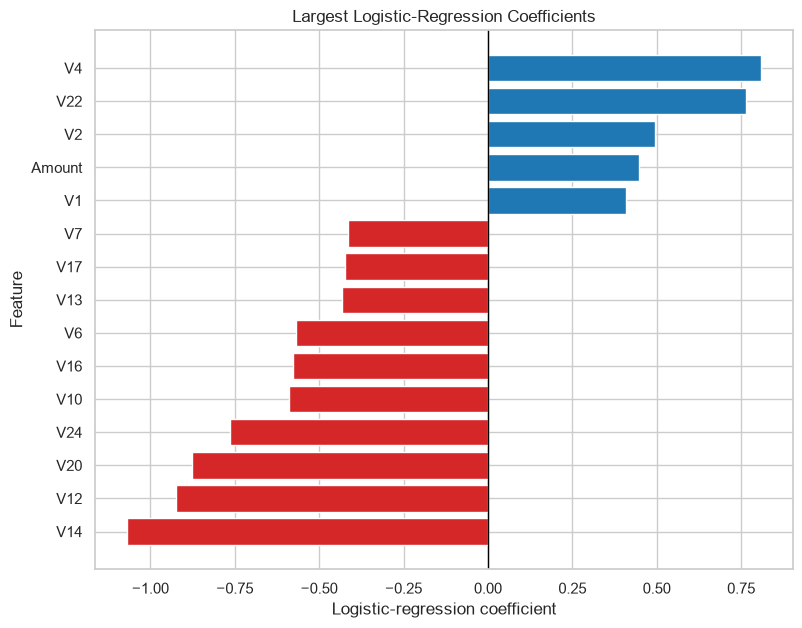

In [19]:
top_coefficients = coefficient_df.head(15).sort_values(
    "coefficient"
)

plt.figure(figsize=(9, 7))

colors = [
    "tab:red" if value < 0 else "tab:blue"
    for value in top_coefficients["coefficient"]
]

plt.barh(
    top_coefficients["feature"],
    top_coefficients["coefficient"],
    color=colors,
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Logistic-regression coefficient")
plt.ylabel("Feature")
plt.title("Largest Logistic-Regression Coefficients")
plt.show()

## Threshold selection and error analysis

At an illustrative review capacity of 100 transactions, logistic regression
detected 45 of 57 fraud cases. This produced 45% alert precision and 78.95%
fraud recall.

Increasing review capacity improved recall but reduced precision, demonstrating
the trade-off between fraud losses and investigation workload. The operating
point is therefore a business decision rather than a purely statistical one.

The default probability threshold of 0.5 generated substantially more alerts.
A capacity-based policy produced a more practical alert queue by ranking
transactions and reviewing only the highest-risk cases.

Feature interpretation is limited because V1–V28 are anonymous PCA components.
Coefficient direction and magnitude can describe model behaviour, but cannot be
translated into merchant, customer or device characteristics.